In [1]:
# Cell 1 — Load topic-level review data

import pandas as pd
from pathlib import Path

relative_path = Path("data/processed/complaints_topic_model.pkl")

project_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / relative_path).is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        f"Không tìm thấy file: {relative_path}"
    )

topic_path = project_root / relative_path

topic_df = pd.read_pickle(topic_path)

print("Project root:", project_root)
print("Shape:", topic_df.shape)

print("\nColumns:")
print(topic_df.columns.tolist())

print("\nHead:")
display(topic_df.head())

Project root: d:\data mining\e_waste_topic_modeling
Shape: (130738, 18)

Columns:
['asin', 'reviewText', 'summary', 'overall', 'review_date', 'year', 'final_tokens', 'lda_text', 'dominant_topic', 'topic_probability', 'topic_0_prob', 'topic_1_prob', 'topic_2_prob', 'topic_3_prob', 'topic_4_prob', 'topic_5_prob', 'topic_6_prob', 'topic_7_prob']

Head:


,asin,reviewText,summary,overall,review_date,year,final_tokens,lda_text,dominant_topic,topic_probability,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob
3,7508492919,DON'T CARE FOR IT. GAVE IT AS A GIFT AND THEY...,CASE,2.0,2014-02-04,2014,"[not, care, give, gift, okay, not, expect]",not care give gift okay not expect,6,0.554145,0.010421,0.010422,0.010424,0.383325,0.010423,0.010421,0.554145,0.010420
5,7508492919,The product looked exactly like the picture an...,Not so happy,2.0,2014-01-27,2014,"[product, look, exactly, like, picture, nice, ...",product look exactly like picture nice however...,6,0.461288,0.005004,0.373378,0.005009,0.140312,0.005003,0.005003,0.461288,0.005004
8,7508492919,DO NOT BUY! this item is seriously cheap as he...,WORST ITEM!,1.0,2013-12-27,2013,"[not, buy, item, seriously, cheap, heck, not, ...",not buy item seriously cheap heck not worth bu...,6,0.487617,0.003574,0.136503,0.003574,0.358009,0.003575,0.003574,0.487617,0.003574
12,7508492919,Very cheap broke the first time we put it on :...,cheap plastic,1.0,2013-10-08,2013,"[cheap, break, first, time, put, EMOTION_SAD, ...",cheap break first time put EMOTION_SAD pretty ...,6,0.446231,0.006588,0.373891,0.006591,0.006583,0.006583,0.006583,0.446231,0.146951
17,7508492919,I used this case for not even a week and the b...,....,2.0,2013-06-27,2013,"[use, case, not, even, week, bow, come, love, ...",use case not even week bow come love pretty wi...,6,0.432348,0.005956,0.203788,0.334075,0.005959,0.005957,0.005957,0.432348,0.005961


In [2]:
# Cell 2 — Aggregate topic probabilities by ASIN

topic_prob_cols = [
    f"topic_{topic_id}_prob"
    for topic_id in range(8)
]

asin_topic_df = (
    topic_df
    .groupby("asin")[topic_prob_cols]
    .mean()
    .reset_index()
)

print("ASIN-level shape:", asin_topic_df.shape)

print("\nNumber of unique ASINs:")
print(asin_topic_df["asin"].nunique())

print("\nTopic profile:")
display(asin_topic_df.head())

ASIN-level shape: (33577, 9)

Number of unique ASINs:
33577

Topic profile:


,asin,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob
0,7508492919,0.006091,0.194903,0.109432,0.181972,0.006091,0.006091,0.397773,0.097646
1,7532385086,0.018469,0.056156,0.251318,0.072475,0.018474,0.018468,0.546172,0.018468
2,7887421268,0.006859,0.086460,0.479389,0.072223,0.006859,0.006857,0.254253,0.087099
3,8199900164,0.007356,0.307126,0.007358,0.007356,0.206067,0.450014,0.007365,0.007358
4,8288853439,0.003862,0.069406,0.003862,0.148630,0.003866,0.616824,0.149686,0.003863


In [3]:
# Cell 3 — Add complaint review count per ASIN

asin_review_count = (
    topic_df
    .groupby("asin")
    .size()
    .reset_index(name="complaint_review_count")
)

asin_topic_df = asin_topic_df.merge(
    asin_review_count,
    on="asin",
    how="left"
)

print("Shape:", asin_topic_df.shape)

print("\nComplaint review count statistics:")
display(
    asin_topic_df["complaint_review_count"]
    .describe()
)

print("\nASIN-level topic profile:")
display(asin_topic_df.head())

Shape: (33577, 10)

Complaint review count statistics:


count    33577.000000
mean         3.893677
std          6.616882
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        233.000000
Name: complaint_review_count, dtype: float64


ASIN-level topic profile:


,asin,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,complaint_review_count
0,7508492919,0.006091,0.194903,0.109432,0.181972,0.006091,0.006091,0.397773,0.097646,6
1,7532385086,0.018469,0.056156,0.251318,0.072475,0.018474,0.018468,0.546172,0.018468,3
2,7887421268,0.006859,0.086460,0.479389,0.072223,0.006859,0.006857,0.254253,0.087099,5
3,8199900164,0.007356,0.307126,0.007358,0.007356,0.206067,0.450014,0.007365,0.007358,1
4,8288853439,0.003862,0.069406,0.003862,0.148630,0.003866,0.616824,0.149686,0.003863,3


In [4]:
# Cell 4 — Prepare K-Means datasets

cluster_features = [
    f"topic_{topic_id}_prob"
    for topic_id in range(8)
]

# Full dataset
asin_cluster_full = asin_topic_df[
    ["asin", "complaint_review_count"] + cluster_features
].copy()

# More reliable subset: at least 3 complaint reviews
asin_cluster = asin_cluster_full[
    asin_cluster_full["complaint_review_count"] >= 3
].copy()

print("Full ASIN dataset:", asin_cluster_full.shape)
print("K-Means dataset  :", asin_cluster.shape)

print(
    "\nExcluded ASINs:",
    len(asin_cluster_full) - len(asin_cluster)
)

print(
    "Excluded percentage:",
    round(
        (1 - len(asin_cluster) / len(asin_cluster_full)) * 100,
        2
    ),
    "%"
)

print("\nReview-count distribution in K-Means dataset:")
display(
    asin_cluster["complaint_review_count"].describe()
)

Full ASIN dataset: (33577, 10)
K-Means dataset  : (13932, 10)

Excluded ASINs: 19645
Excluded percentage: 58.51 %

Review-count distribution in K-Means dataset:


count    13932.000000
mean         7.441071
std          9.147844
min          3.000000
25%          3.000000
50%          5.000000
75%          8.000000
max        233.000000
Name: complaint_review_count, dtype: float64

In [5]:
# Cell 5 — Standardize topic-profile features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    asin_cluster[cluster_features]
)

print("Original feature shape:", asin_cluster[cluster_features].shape)
print("Scaled feature shape:", X_cluster.shape)

print("\nFeature means after scaling:")
print(X_cluster.mean(axis=0).round(6))

print("\nFeature std after scaling:")
print(X_cluster.std(axis=0).round(6))

Original feature shape: (13932, 8)
Scaled feature shape: (13932, 8)

Feature means after scaling:
[ 0.  0. -0. -0. -0.  0. -0. -0.]

Feature std after scaling:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [6]:
# Cell 6 — Evaluate candidate K values

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster, labels)
    )

k_evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette": silhouette_scores
})

display(k_evaluation)

,K,Inertia,Silhouette
0,2,92867.512774,0.207229
1,3,78259.183637,0.236615
2,4,65456.633065,0.284924
3,5,54855.425752,0.309425
4,6,47360.980219,0.305953
5,7,41592.570652,0.312468
6,8,36246.171408,0.319488


In [7]:
# Cell 7 — Extend K evaluation

k_values_extended = range(2, 13)

inertias_extended = []
silhouette_extended = []

for k in k_values_extended:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster)

    inertias_extended.append(kmeans.inertia_)
    silhouette_extended.append(
        silhouette_score(X_cluster, labels)
    )

k_evaluation_extended = pd.DataFrame({
    "K": list(k_values_extended),
    "Inertia": inertias_extended,
    "Silhouette": silhouette_extended
})

display(k_evaluation_extended)

,K,Inertia,Silhouette
0,2,92867.512774,0.207229
1,3,78259.183637,0.236615
2,4,65456.633065,0.284924
3,5,54855.425752,0.309425
4,6,47360.980219,0.305953
5,7,41592.570652,0.312468
6,8,36246.171408,0.319488
7,9,34669.572302,0.296892
8,10,33342.250362,0.268522
9,11,32315.453877,0.251460


In [8]:
# Cell 8 — Final K-Means model with K=8

final_k = 8

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

asin_cluster["cluster"] = kmeans_final.fit_predict(X_cluster)

print("Final K:", final_k)
print("Number of ASINs:", len(asin_cluster))
print("\nCluster sizes:")

cluster_sizes = (
    asin_cluster["cluster"]
    .value_counts()
    .sort_index()
)

display(cluster_sizes.to_frame("asin_count"))

Final K: 8
Number of ASINs: 13932

Cluster sizes:


,asin_count
cluster,
0,1367
1,3061
2,1859
3,1372
4,1335
5,1575
6,1342
7,2021


In [9]:
# Cell 9 — Analyze cluster centroids

centroid_df = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=cluster_features
)

centroid_df.index.name = "cluster"

display(
    centroid_df.round(4)
)

,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob
cluster,,,,,,,,
0,-0.4673,-0.3299,-0.7496,0.0680,2.6648,-0.2122,-0.5763,-0.3904
1,-0.2720,-0.3027,1.5356,-0.3583,-0.3302,-0.4415,-0.2032,-0.2426
2,2.2936,-0.4388,-0.6478,-0.1539,-0.3808,-0.5148,-0.2221,-0.4851
3,-0.4357,-0.0788,-0.3433,-0.3799,-0.3143,-0.3859,-0.1779,2.4999
4,-0.4466,2.2405,-0.4846,-0.2355,-0.2858,0.3196,-0.3657,-0.1518
5,-0.5351,0.1770,-0.6859,-0.0374,-0.2896,2.4023,-0.5510,-0.3062
6,-0.1300,-0.2095,-0.2787,2.0435,-0.0267,-0.1971,-0.1291,-0.2264
7,-0.2877,-0.3392,0.0475,-0.2769,-0.3052,-0.4056,1.7821,-0.1300


In [10]:
# Cell 10 — Convert centroids back to original topic-probability scale

centroid_original = pd.DataFrame(
    scaler.inverse_transform(
        kmeans_final.cluster_centers_
    ),
    columns=cluster_features
)

centroid_original.index.name = "cluster"

display(
    centroid_original.round(4)
)

,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob
cluster,,,,,,,,
0,0.0286,0.0822,0.0316,0.1196,0.5423,0.0621,0.0893,0.0441
1,0.0662,0.0855,0.4931,0.0796,0.0454,0.0250,0.1410,0.0641
2,0.5602,0.0690,0.0522,0.0987,0.0371,0.0131,0.1384,0.0313
3,0.0347,0.1128,0.1137,0.0775,0.0481,0.0340,0.1445,0.4346
4,0.0326,0.3951,0.0851,0.0911,0.0528,0.1483,0.1185,0.0764
5,0.0156,0.1439,0.0445,0.1097,0.0522,0.4858,0.0928,0.0555
6,0.0936,0.0969,0.1267,0.3048,0.0958,0.0646,0.1513,0.0663
7,0.0632,0.0811,0.1926,0.0872,0.0496,0.0308,0.4162,0.0793


In [11]:
# Cell 11 — Identify dominant topic for each cluster

cluster_profile = centroid_original.copy()

cluster_profile["dominant_topic"] = (
    cluster_profile[cluster_features]
    .idxmax(axis=1)
)

cluster_profile["dominant_topic_probability"] = (
    cluster_profile[cluster_features]
    .max(axis=1)
)

cluster_profile["asin_count"] = (
    asin_cluster["cluster"]
    .value_counts()
    .sort_index()
    .values
)

display(
    cluster_profile[
        [
            "dominant_topic",
            "dominant_topic_probability",
            "asin_count"
        ]
    ].round(4)
)

,dominant_topic,dominant_topic_probability,asin_count
cluster,,,
0,topic_4_prob,0.5423,1367
1,topic_2_prob,0.4931,3061
2,topic_0_prob,0.5602,1859
3,topic_7_prob,0.4346,1372
4,topic_1_prob,0.3951,1335
5,topic_5_prob,0.4858,1575
6,topic_3_prob,0.3048,1342
7,topic_6_prob,0.4162,2021


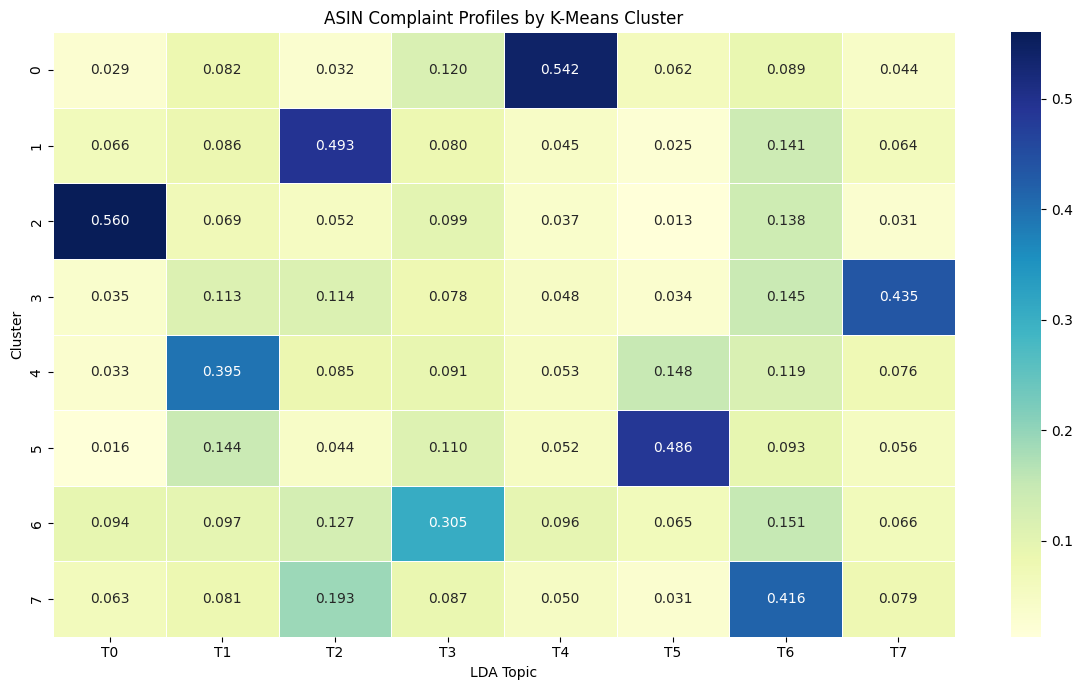

In [12]:
# Cell 12 — Cluster profile heatmap

import matplotlib.pyplot as plt
import seaborn as sns

heatmap_df = centroid_original.copy()

heatmap_df.columns = [
    f"T{i}"
    for i in range(8)
]

plt.figure(figsize=(12, 7))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("ASIN Complaint Profiles by K-Means Cluster")
plt.xlabel("LDA Topic")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

In [13]:
# Cell 13 — Create interpretable cluster labels

topic_labels = {
    0: "Screen-related",
    1: "Durability / work-break",
    2: "Case / cover",
    3: "Product / return / order",
    4: "Phone / call / sound",
    5: "Charging / battery",
    6: "Fit / quality / value",
    7: "Mount / holder"
}

cluster_names = {
    0: "Phone / call / sound",
    1: "Case / cover",
    2: "Screen-related",
    3: "Mount / holder",
    4: "Durability / work-break",
    5: "Charging / battery",
    6: "Product / return / order",
    7: "Fit / quality / value"
}

cluster_summary = cluster_profile.reset_index().copy()

cluster_summary["profile"] = (
    cluster_summary["cluster"]
    .map(cluster_names)
)

cluster_summary = cluster_summary[
    [
        "cluster",
        "profile",
        "dominant_topic",
        "dominant_topic_probability",
        "asin_count"
    ]
]

display(
    cluster_summary.sort_values("cluster").round(4)
)

,cluster,profile,dominant_topic,dominant_topic_probability,asin_count
0,0,Phone / call / sound,topic_4_prob,0.5423,1367
1,1,Case / cover,topic_2_prob,0.4931,3061
2,2,Screen-related,topic_0_prob,0.5602,1859
3,3,Mount / holder,topic_7_prob,0.4346,1372
4,4,Durability / work-break,topic_1_prob,0.3951,1335
5,5,Charging / battery,topic_5_prob,0.4858,1575
6,6,Product / return / order,topic_3_prob,0.3048,1342
7,7,Fit / quality / value,topic_6_prob,0.4162,2021


In [14]:
# Cell 14 — Save final K-Means results

cluster_output_path = project_root / "data/processed/asin_kmeans_profiles.pkl"
cluster_summary_path = project_root / "data/processed/asin_kmeans_summary.pkl"

# Save ASIN-level clustering results
asin_cluster.to_pickle(cluster_output_path)

# Save cluster-level summary
cluster_summary.to_pickle(cluster_summary_path)

print("ASIN profiles saved:", cluster_output_path)
print("Cluster summary saved:", cluster_summary_path)

print("\nASIN profile shape:", asin_cluster.shape)
print("Cluster summary shape:", cluster_summary.shape)

ASIN profiles saved: d:\data mining\e_waste_topic_modeling\data\processed\asin_kmeans_profiles.pkl
Cluster summary saved: d:\data mining\e_waste_topic_modeling\data\processed\asin_kmeans_summary.pkl

ASIN profile shape: (13932, 11)
Cluster summary shape: (8, 5)


In [15]:
# Cell 15 — Analyze failure-related clusters

failure_cluster_map = {
    2: "T0 - Screen-related",
    4: "T1 - Durability / work-break",
    5: "T5 - Charging / battery"
}

failure_clusters = asin_cluster[
    asin_cluster["cluster"].isin(failure_cluster_map.keys())
].copy()

failure_clusters["failure_profile"] = (
    failure_clusters["cluster"]
    .map(failure_cluster_map)
)

failure_summary = (
    failure_clusters
    .groupby(["cluster", "failure_profile"])
    .agg(
        asin_count=("asin", "nunique"),
        complaint_review_count=(
            "complaint_review_count",
            "sum"
        ),
        avg_reviews_per_asin=(
            "complaint_review_count",
            "mean"
        )
    )
    .reset_index()
)

display(
    failure_summary.round(2)
)

,cluster,failure_profile,asin_count,complaint_review_count,avg_reviews_per_asin
0,2,T0 - Screen-related,1859,16194,8.71
1,4,T1 - Durability / work-break,1335,9129,6.84
2,5,T5 - Charging / battery,1575,13915,8.83


In [16]:
# Cell 16 — Failure-related profile proportions

total_asins = len(asin_cluster)

total_complaint_reviews = (
    asin_cluster["complaint_review_count"].sum()
)

failure_asins = failure_summary["asin_count"].sum()

failure_complaint_reviews = (
    failure_summary["complaint_review_count"].sum()
)

failure_share = pd.DataFrame({
    "metric": [
        "ASINs in K-Means dataset",
        "Failure-related ASINs",
        "Failure-related ASIN share (%)",
        "Complaint reviews in K-Means dataset",
        "Failure-related complaint reviews",
        "Failure-related complaint review share (%)"
    ],
    "value": [
        total_asins,
        failure_asins,
        failure_asins / total_asins * 100,
        total_complaint_reviews,
        failure_complaint_reviews,
        failure_complaint_reviews / total_complaint_reviews * 100
    ]
})

display(failure_share.round(2))

,metric,value
0,ASINs in K-Means dataset,13932.00
1,Failure-related ASINs,4769.00
2,Failure-related ASIN share (%),34.23
3,Complaint reviews in K-Means dataset,103669.00
4,Failure-related complaint reviews,39238.00
5,Failure-related complaint review share (%),37.85


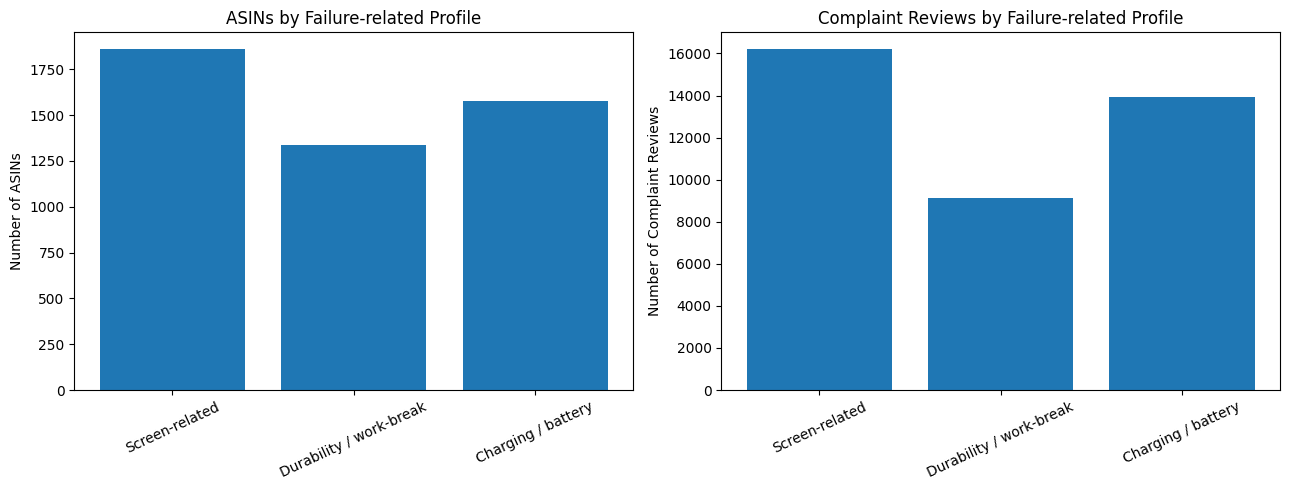

In [17]:
# Cell 17 — Failure-related profile comparison

plot_df = failure_summary.copy()

plot_df["profile"] = plot_df["failure_profile"].str.replace(
    r"^T\d+ - ",
    "",
    regex=True
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

# ASIN count
axes[0].bar(
    plot_df["profile"],
    plot_df["asin_count"]
)

axes[0].set_title("ASINs by Failure-related Profile")
axes[0].set_ylabel("Number of ASINs")
axes[0].tick_params(axis="x", rotation=25)

# Complaint review count
axes[1].bar(
    plot_df["profile"],
    plot_df["complaint_review_count"]
)

axes[1].set_title("Complaint Reviews by Failure-related Profile")
axes[1].set_ylabel("Number of Complaint Reviews")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [18]:
# Cell 18 — Save final clustering analysis

failure_summary_path = (
    project_root / "data/processed/failure_cluster_summary.pkl"
)

failure_share_path = (
    project_root / "data/processed/failure_profile_share.pkl"
)

failure_summary.to_pickle(failure_summary_path)
failure_share.to_pickle(failure_share_path)

print("Saved failure summary:", failure_summary_path)
print("Saved failure share:", failure_share_path)

print("\nFailure summary shape:", failure_summary.shape)
print("Failure share shape:", failure_share.shape)

Saved failure summary: d:\data mining\e_waste_topic_modeling\data\processed\failure_cluster_summary.pkl
Saved failure share: d:\data mining\e_waste_topic_modeling\data\processed\failure_profile_share.pkl

Failure summary shape: (3, 5)
Failure share shape: (6, 2)
